---

Exploring Classification Models pre-processing, training, and validation. Review performance

* Predict sex of the possum
* Utilize Precision/Recall Curves, Area under the curve and confusion matrix
* Look into Unsupervised learning at the end

---

In [1]:
import pandas as pd
import numpy as np

In [2]:
from pathlib import Path

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,roc_auc_score,classification_report,accuracy_score, ConfusionMatrixDisplay

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
possum_dataset = pd.read_csv(Path('data','possum.csv'))
possum_dataset

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,100,7,other,m,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,101,7,other,m,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,102,7,other,f,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,103,7,other,m,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


In [6]:
possum_dataset.describe()

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
count,104.000000,104.000000,102.000000,104.000000,104.000000,104.000000,104.000000,103.000000,104.000000,104.000000,104.000000,104.000000
mean,52.500000,3.625000,3.833333,92.602885,56.883654,87.088462,37.009615,68.459223,48.130769,15.046154,27.000000,32.586538
std,30.166206,2.349086,1.909244,3.573349,3.113426,4.310549,1.959518,4.395306,4.109380,1.050374,2.045597,2.761949
min,1.000000,1.000000,1.000000,82.500000,50.000000,75.000000,32.000000,60.300000,40.300000,12.800000,22.000000,25.000000
25%,26.750000,1.000000,2.250000,90.675000,54.975000,84.000000,35.875000,64.600000,44.800000,14.400000,25.500000,31.000000
50%,52.500000,3.000000,3.000000,92.800000,56.350000,88.000000,37.000000,68.000000,46.800000,14.900000,27.000000,32.500000
75%,78.250000,6.000000,5.000000,94.725000,58.100000,90.000000,38.000000,72.500000,52.000000,15.725000,28.000000,34.125000
max,104.000000,7.000000,9.000000,103.100000,68.600000,96.500000,43.000000,77.900000,56.200000,17.800000,32.000000,40.000000


In [7]:
nan_counts_per_column = possum_dataset.isna().sum()
print(nan_counts_per_column)

case        0
site        0
Pop         0
sex         0
age         2
hdlngth     0
skullw      0
totlngth    0
taill       0
footlgth    1
earconch    0
eye         0
chest       0
belly       0
dtype: int64


In [8]:
nan_rows = possum_dataset[possum_dataset.isna().any(axis=1)]
print(nan_rows)

    case  site  Pop sex  age  hdlngth  skullw  totlngth  taill  footlgth  \
40    41     2  Vic   f  5.0     88.4    57.0      83.0   36.5       NaN   
43    44     2  Vic   m  NaN     85.1    51.5      76.0   35.5      70.3   
45    46     2  Vic   m  NaN     91.4    54.4      84.0   35.0      72.8   

    earconch   eye  chest  belly  
40      40.3  15.9   27.0   30.5  
43      52.6  14.4   23.0   27.0  
45      51.2  14.4   24.5   35.0  


In [9]:
possum_dataset_processed = possum_dataset.dropna()
possum_dataset_processed

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,100,7,other,m,1.0,89.5,56.0,81.5,36.5,66.0,46.8,14.8,23.0,27.0
100,101,7,other,m,1.0,88.6,54.7,82.5,39.0,64.4,48.0,14.0,25.0,33.0
101,102,7,other,f,6.0,92.4,55.0,89.0,38.0,63.5,45.4,13.0,25.0,30.0
102,103,7,other,m,4.0,91.5,55.2,82.5,36.5,62.9,45.9,15.4,25.0,29.0


array([[<Axes: title={'center': 'case'}>,
        <Axes: title={'center': 'site'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'hdlngth'}>,
        <Axes: title={'center': 'skullw'}>,
        <Axes: title={'center': 'totlngth'}>],
       [<Axes: title={'center': 'taill'}>,
        <Axes: title={'center': 'footlgth'}>,
        <Axes: title={'center': 'earconch'}>],
       [<Axes: title={'center': 'eye'}>,
        <Axes: title={'center': 'chest'}>,
        <Axes: title={'center': 'belly'}>]], dtype=object)

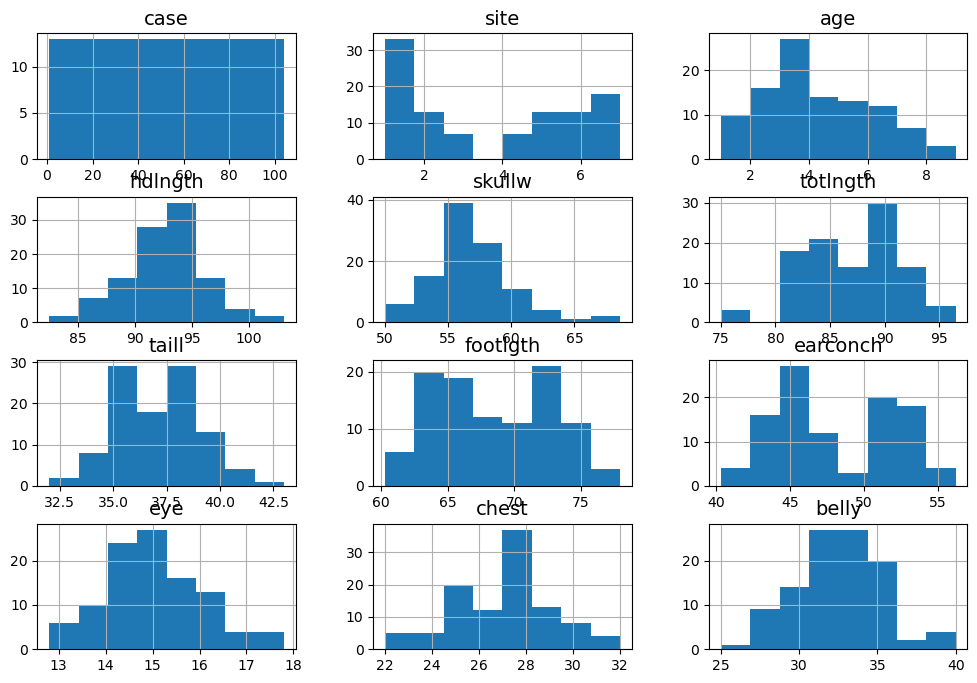

In [10]:
# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

possum_dataset.hist(bins=8, figsize=(12, 8))

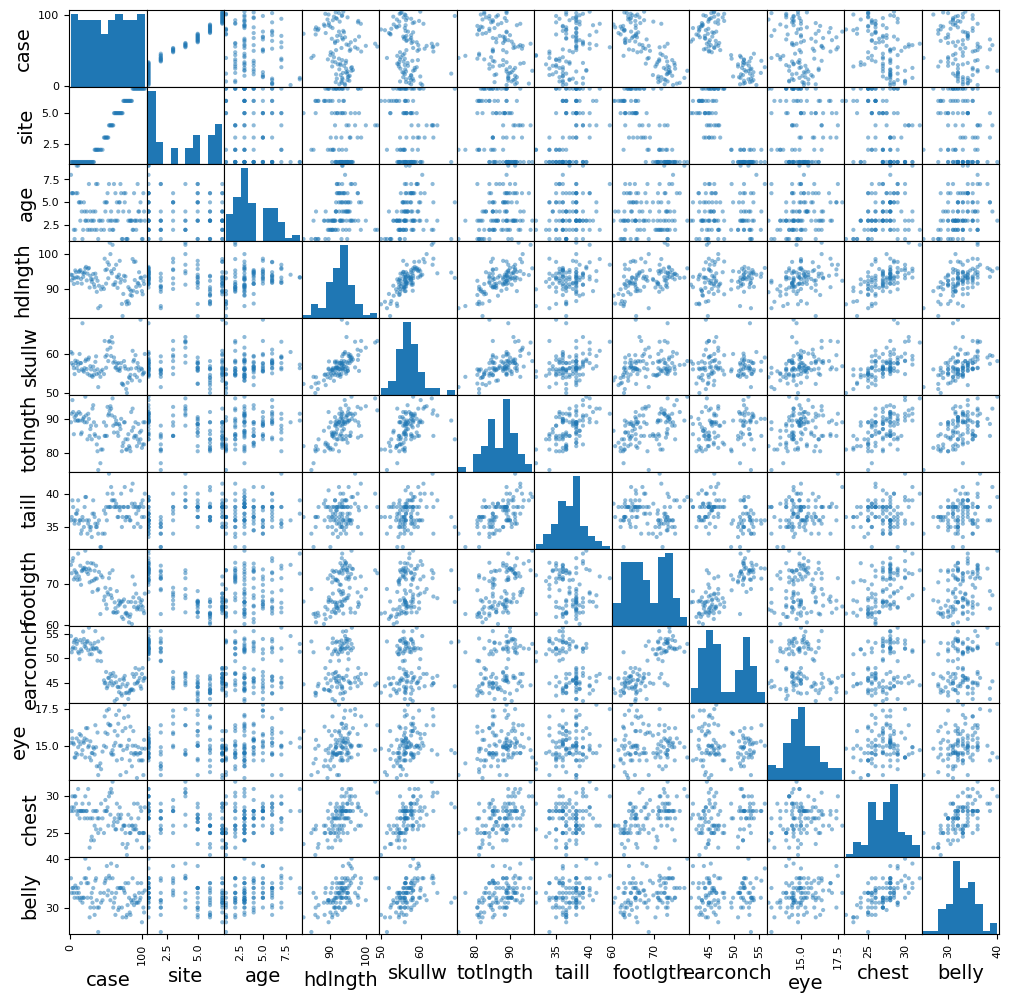

In [11]:
# Generate the scatter matrix
pd.plotting.scatter_matrix(possum_dataset_processed, figsize=(12, 12))
plt.show()

In [12]:
numerical_columns_list = list(possum_dataset.select_dtypes(include=np.number).columns)
numerical_columns_list

['case',
 'site',
 'age',
 'hdlngth',
 'skullw',
 'totlngth',
 'taill',
 'footlgth',
 'earconch',
 'eye',
 'chest',
 'belly']

---

* Simple Linear regression model setup above

* Next setup a pipeline

    - Utilize imputer
    - Process the data by scaling using minmax
    - Setup train and test data using age histogram
    - Use different models mentioned in the end to end machine learning project of the Hands-on ML book
    - Select the best model

---

In [13]:
possum_dataset.sample(n=10)

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
23,24,1,Vic,m,2.0,94.4,54.9,84.0,34.0,75.0,53.5,16.2,27.0,32.0
82,83,6,other,f,3.0,90.0,53.8,81.5,36.0,62.0,43.3,14.0,25.0,29.0
30,31,1,Vic,m,3.0,92.8,54.1,93.0,37.0,68.0,52.5,14.5,27.0,31.0
88,89,7,other,m,6.0,97.7,58.4,84.5,35.0,64.4,46.2,14.4,29.0,30.5
20,21,1,Vic,f,3.0,95.9,58.1,96.5,39.5,77.9,52.9,14.2,30.0,40.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
43,44,2,Vic,m,NaN,85.1,51.5,76.0,35.5,70.3,52.6,14.4,23.0,27.0
73,74,6,other,f,4.0,88.7,52.0,83.0,38.0,61.5,45.9,14.7,26.0,34.0
45,46,2,Vic,m,NaN,91.4,54.4,84.0,35.0,72.8,51.2,14.4,24.5,35.0
91,92,7,other,m,2.0,90.7,56.3,85.0,37.0,67.6,46.8,14.5,25.5,31.0


In [14]:
possum_dataset['log_age']=np.log(possum_dataset['age'])
possum_dataset['exp_dec_age']=np.exp(-possum_dataset['age'])
possum_dataset['tanh_age']=np.tanh(possum_dataset['age'])

In [15]:
numerical_columns_list = list(possum_dataset.select_dtypes(include=np.number).columns)
numerical_columns_list

['case',
 'site',
 'age',
 'hdlngth',
 'skullw',
 'totlngth',
 'taill',
 'footlgth',
 'earconch',
 'eye',
 'chest',
 'belly',
 'log_age',
 'exp_dec_age',
 'tanh_age']

In [16]:
from sklearn.impute import SimpleImputer

most_frequent_imputer = SimpleImputer(strategy="most_frequent")

In [17]:
most_frequent_imputer.fit(possum_dataset[numerical_columns_list])

SimpleImputer(strategy='most_frequent')

In [18]:
#help(SimpleImputer)

In [19]:
most_frequent_imputer.statistics_

array([1.00000000e+00, 1.00000000e+00, 3.00000000e+00, 9.33000000e+01,
       5.76000000e+01, 8.90000000e+01, 3.80000000e+01, 7.32000000e+01,
       4.49000000e+01, 1.44000000e+01, 2.80000000e+01, 3.20000000e+01,
       1.09861229e+00, 4.97870684e-02, 9.95054754e-01])

In [20]:
median_imputer = SimpleImputer(strategy="median")

In [21]:
median_imputer.fit(possum_dataset[numerical_columns_list])
print(median_imputer.statistics_)

[5.25000000e+01 3.00000000e+00 3.00000000e+00 9.28000000e+01
 5.63500000e+01 8.80000000e+01 3.70000000e+01 6.80000000e+01
 4.68000000e+01 1.49000000e+01 2.70000000e+01 3.25000000e+01
 1.09861229e+00 4.97870684e-02 9.95054754e-01]


In [22]:
median_imputer

SimpleImputer(strategy='median')

In [23]:
mean_imputer = SimpleImputer(strategy="mean")

In [24]:
mean_imputer.fit(possum_dataset[numerical_columns_list])
print(mean_imputer.statistics_)

[5.25000000e+01 3.62500000e+00 3.83333333e+00 9.26028846e+01
 5.68836538e+01 8.70884615e+01 3.70096154e+01 6.84592233e+01
 4.81307692e+01 1.50461538e+01 2.70000000e+01 3.25865385e+01
 1.20274584e+00 7.42071816e-02 9.69569918e-01]


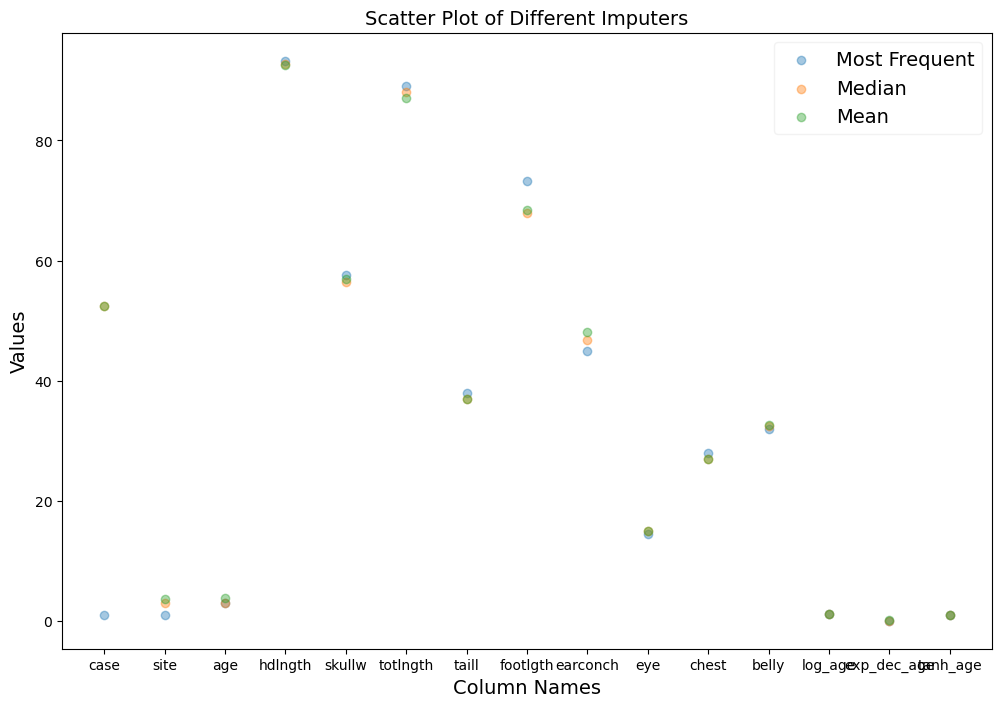

In [25]:
plt.figure(figsize=(12, 8))
plt.scatter(numerical_columns_list, 
            most_frequent_imputer.statistics_, 
            label="Most Frequent",
            alpha=0.4)
plt.scatter(numerical_columns_list, 
            median_imputer.statistics_, 
            label="Median",
            alpha=0.4)
plt.scatter(numerical_columns_list, 
            mean_imputer.statistics_, 
            label="Mean",
            alpha=0.4)
plt.legend(loc='upper right', framealpha=0.25)
plt.xlabel("Column Names")
plt.ylabel("Values")
plt.title("Scatter Plot of Different Imputers")
plt.show()

In [26]:
X = median_imputer.transform(possum_dataset[numerical_columns_list])
print(median_imputer.feature_names_in_)
print(X[:5,:])

['case' 'site' 'age' 'hdlngth' 'skullw' 'totlngth' 'taill' 'footlgth'
 'earconch' 'eye' 'chest' 'belly' 'log_age' 'exp_dec_age' 'tanh_age']
[[1.00000000e+00 1.00000000e+00 8.00000000e+00 9.41000000e+01
  6.04000000e+01 8.90000000e+01 3.60000000e+01 7.45000000e+01
  5.45000000e+01 1.52000000e+01 2.80000000e+01 3.60000000e+01
  2.07944154e+00 3.35462628e-04 9.99999775e-01]
 [2.00000000e+00 1.00000000e+00 6.00000000e+00 9.25000000e+01
  5.76000000e+01 9.15000000e+01 3.65000000e+01 7.25000000e+01
  5.12000000e+01 1.60000000e+01 2.85000000e+01 3.30000000e+01
  1.79175947e+00 2.47875218e-03 9.99987712e-01]
 [3.00000000e+00 1.00000000e+00 6.00000000e+00 9.40000000e+01
  6.00000000e+01 9.55000000e+01 3.90000000e+01 7.54000000e+01
  5.19000000e+01 1.55000000e+01 3.00000000e+01 3.40000000e+01
  1.79175947e+00 2.47875218e-03 9.99987712e-01]
 [4.00000000e+00 1.00000000e+00 6.00000000e+00 9.32000000e+01
  5.71000000e+01 9.20000000e+01 3.80000000e+01 7.61000000e+01
  5.22000000e+01 1.52000000e+01 2.

In [27]:
possum_dataset_median_transformed = pd.DataFrame(X, 
                                                 columns=numerical_columns_list,
                                                 index=possum_dataset.index
                                                )
possum_dataset_median_transformed.sample(10)

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly,log_age,exp_dec_age,tanh_age
31,32.0,1.0,4.0,94.3,56.7,94.0,39.0,74.8,52.0,14.9,28.0,34.0,1.386294,0.018316,0.999329
88,89.0,7.0,6.0,97.7,58.4,84.5,35.0,64.4,46.2,14.4,29.0,30.5,1.791759,0.002479,0.999988
57,58.0,4.0,3.0,94.5,64.2,91.0,39.0,66.5,46.4,14.4,30.5,33.0,1.098612,0.049787,0.995055
60,61.0,5.0,7.0,95.7,59.0,86.0,38.0,63.1,44.9,15.0,26.5,31.0,1.945910,0.000912,0.999998
43,44.0,2.0,3.0,85.1,51.5,76.0,35.5,70.3,52.6,14.4,23.0,27.0,1.098612,0.049787,0.995055
91,92.0,7.0,2.0,90.7,56.3,85.0,37.0,67.6,46.8,14.5,25.5,31.0,0.693147,0.135335,0.964028
54,55.0,4.0,2.0,103.1,63.2,92.5,38.0,72.5,44.9,16.4,30.5,36.0,0.693147,0.135335,0.964028
17,18.0,1.0,2.0,93.5,55.7,90.0,36.0,73.7,55.4,15.3,28.0,32.0,0.693147,0.135335,0.964028
56,57.0,4.0,4.0,95.1,59.4,93.0,41.0,67.2,45.3,14.5,31.0,39.0,1.386294,0.018316,0.999329
16,17.0,1.0,1.0,94.7,67.7,89.5,36.5,73.2,53.2,14.7,29.0,31.0,0.000000,0.367879,0.761594


In [28]:
# check if imputer worked
nan_counts_per_column_tr = possum_dataset_median_transformed.isna().sum()
print(nan_counts_per_column_tr)

case           0
site           0
age            0
hdlngth        0
skullw         0
totlngth       0
taill          0
footlgth       0
earconch       0
eye            0
chest          0
belly          0
log_age        0
exp_dec_age    0
tanh_age       0
dtype: int64


---

* Look into shuffling dataset into test and train utilizing age of possum

---

<Axes: >

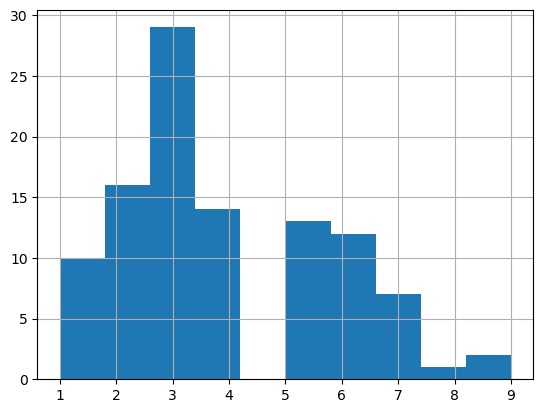

In [29]:
possum_dataset_median_transformed.age.hist()

In [30]:
possum_dataset_median_transformed["age_cat"] = pd.cut(possum_dataset_median_transformed["age"],
                               bins=[0., 2.5, 3.5, 4., 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

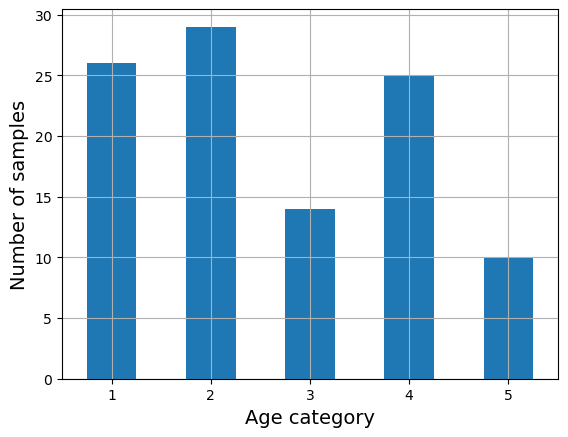

In [31]:
possum_dataset_median_transformed["age_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Age category")
plt.ylabel("Number of samples")
plt.show()

In [32]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
possum_data_strat_splits = []
for train_index, test_index in splitter.split(possum_dataset_median_transformed, 
                                              possum_dataset_median_transformed["age_cat"]):
    possum_data_train_set_n = possum_dataset_median_transformed.iloc[train_index]
    possum_data_test_set_n = possum_dataset_median_transformed.iloc[test_index]
    possum_data_strat_splits.append([possum_data_train_set_n, possum_data_test_set_n])

In [33]:
possum_data_train_set, possum_data_test_set = possum_data_strat_splits[0]

In [34]:
possum_data_train_set, possum_data_test_set = train_test_split(
    possum_dataset_median_transformed, 
    test_size=0.2, 
    stratify=possum_dataset_median_transformed["age_cat"], 
    random_state=42)

In [35]:
possum_data_test_set["age_cat"].value_counts()/len(possum_data_test_set)

age_cat
2    0.285714
1    0.238095
4    0.238095
3    0.142857
5    0.095238
Name: count, dtype: float64

In [36]:
possum_data_train_set["age_cat"].value_counts()/len(possum_data_train_set)

age_cat
2    0.277108
1    0.253012
4    0.240964
3    0.132530
5    0.096386
Name: count, dtype: float64

In [37]:
possum_data_train_set.index

Index([ 39,  21,  15,  53,  22,  86,  81,  89,  87,  48,  52,  35,  67,  51,
        14,  72,  56,  20,   6, 100,   8,   2,  36,  79,  62,  23,  71,  75,
        77,  95,  49,   9,  61,  13,  66,  12, 101,  24,  99,  64,  94,  55,
        59,  57,  34,   1,  17,  91,  74,  98,   3,  85,  10,  50,   4,  16,
       102,  18,  70,  33,  37,  30,  82,  80,  43,  28,  47,  44,  73,  25,
        96,  46,  97,  88,  54,  65,  83,  42,  41,  93,  32,   5,  60],
      dtype='int64')

<Axes: xlabel='age_cat'>

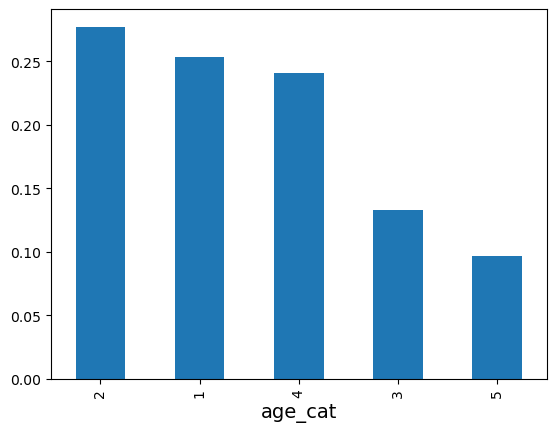

In [38]:
pd.Series(possum_data_train_set["age_cat"].value_counts()/len(possum_data_train_set)).plot.bar()

<Axes: xlabel='age_cat'>

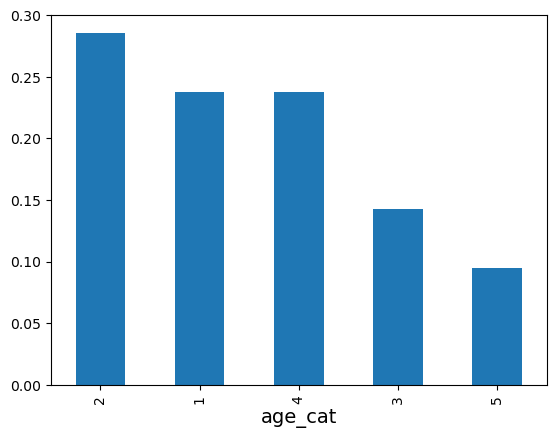

In [39]:
pd.Series(possum_data_test_set["age_cat"].value_counts()/len(possum_data_test_set)).plot.bar()

In [40]:
for set_ in (possum_data_train_set, possum_data_test_set):
    set_.drop("age_cat", axis=1, inplace=True)

---
* Need to add pre-processing of the dataset
---

In [41]:
imputed_scaled_possum_train_dataset=pd.DataFrame()
imputed_scaled_possum_train_dataset[numerical_columns_list] = StandardScaler().fit_transform(possum_data_train_set[numerical_columns_list])
imputed_scaled_possum_train_dataset

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly,log_age,exp_dec_age,tanh_age
0,-0.426935,-0.720662,-0.432167,-0.442222,-0.644089,-0.616049,-0.519922,1.009301,0.810339,-1.443379,-0.064486,-0.952656,-0.181426,-0.229692,0.363515
1,-1.025847,-1.150985,-0.432167,1.112801,0.466343,0.942855,1.278142,1.168261,0.983749,1.040522,0.445263,1.243746,-0.181426,-0.229692,0.363515
2,-1.225485,-1.150985,0.095331,-0.266181,-0.326823,-0.256302,-1.290521,1.054718,0.810339,-0.679102,0.445263,-0.220522,0.332742,-0.527521,0.425324
3,0.038885,0.139985,1.677823,1.288842,1.894042,1.062771,3.076205,0.668672,-0.527392,2.282473,1.464762,1.426779,1.332931,-0.692221,0.434998
4,-0.992574,-1.150985,0.095331,-0.002121,-0.295096,0.463193,-0.519922,1.009301,1.281022,0.276245,0.445263,0.877679,0.332742,-0.527521,0.425324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,-0.360390,-0.720662,-0.432167,-2.114605,-0.929629,-2.414785,-2.574852,-1.284267,0.760794,-1.252310,-0.829111,0.145545,-0.181426,-0.229692,0.363515
79,1.369801,1.430955,1.677823,-0.207501,0.180804,-0.735965,-0.776788,-0.943638,-0.750347,-0.679102,0.955013,0.877679,1.332931,-0.692221,0.434998
80,-0.659846,-1.150985,-0.432167,-0.324862,-0.770996,0.463193,-0.006190,0.555129,0.909430,-0.296963,-1.593735,-0.952656,-0.181426,-0.229692,0.363515
81,-1.558214,-1.150985,-1.487161,0.173919,-0.707542,0.822940,-0.776788,1.100135,1.355341,-0.870171,1.464762,-0.220522,-2.144951,2.780567,-3.012283


In [42]:
imputed_scaled_possum_test_dataset=pd.DataFrame()
imputed_scaled_possum_test_dataset[numerical_columns_list] = StandardScaler().fit_transform(possum_data_test_set[numerical_columns_list])
imputed_scaled_possum_test_dataset

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly,log_age,exp_dec_age,tanh_age
0,-1.312852,-1.019592,0.646360,0.471925,-0.251403,1.020939,-0.763763,0.691676,0.666763,0.509790,0.670820,0.169249,0.738799,-0.626237,0.425120
1,0.429110,0.659736,-0.439525,0.963757,0.069646,0.492867,0.763763,-1.417993,-0.707811,2.310729,-0.447214,0.169249,-0.190205,-0.216098,0.354629
2,-1.681344,-1.019592,2.275186,0.275192,1.460858,0.387253,-0.509175,1.370650,1.482188,0.409738,0.670820,1.235515,1.593563,-0.687235,0.426435
3,-0.642867,-1.019592,0.103418,0.324375,0.140990,1.443396,1.018350,1.443397,0.899741,0.109581,0.670820,0.524671,0.332983,-0.515934,0.416699
4,-1.044858,-1.019592,0.103418,0.447333,-0.001699,0.387253,0.509175,1.200906,0.992933,0.709894,0.223607,1.235515,0.332983,-0.515934,0.416699
5,-0.173877,-0.599760,-0.439525,-0.388782,-0.679469,-0.668891,-1.018350,0.958416,0.713359,-0.390680,-0.894427,0.880093,-0.190205,-0.216098,0.354629
6,1.769080,1.499400,-0.439525,0.152234,1.282497,0.387253,1.527525,-0.302536,-0.498131,0.009529,0.894427,0.346960,-0.190205,-0.216098,0.354629
7,-1.446849,-1.019592,1.189302,0.447333,0.462039,0.809710,0.000000,0.934166,1.342401,-0.290628,1.118034,0.524671,1.070375,-0.666815,0.426260
8,-0.810363,-1.019592,-0.982467,-0.610106,-0.643797,-0.457662,-1.018350,0.352189,0.620167,-0.590784,-1.565248,-1.607862,-0.927597,0.598940,-0.095914
9,-0.709865,-1.019592,-0.982467,-0.216640,-0.679469,-0.668891,-1.782113,0.424936,0.620167,-0.290628,-0.894427,0.169249,-0.927597,0.598940,-0.095914


In [43]:
possum_data_train_set.columns

Index(['case', 'site', 'age', 'hdlngth', 'skullw', 'totlngth', 'taill',
       'footlgth', 'earconch', 'eye', 'chest', 'belly', 'log_age',
       'exp_dec_age', 'tanh_age'],
      dtype='object')

In [44]:
selected_columns = list(possum_data_train_set.columns.values)[2:]
selected_columns

['age',
 'hdlngth',
 'skullw',
 'totlngth',
 'taill',
 'footlgth',
 'earconch',
 'eye',
 'chest',
 'belly',
 'log_age',
 'exp_dec_age',
 'tanh_age']

In [45]:
possum_data_train_set[selected_columns].corr().style.background_gradient(cmap='RdBu', vmin=-1, vmax=1).format(precision=3)

,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly,log_age,exp_dec_age,tanh_age
age,1.000,0.340,0.268,0.255,0.146,0.111,0.036,0.251,0.324,0.297,0.950,-0.737,0.581
hdlngth,0.340,1.000,0.714,0.661,0.256,0.430,0.140,0.339,0.628,0.520,0.387,-0.393,0.390
skullw,0.268,0.714,1.000,0.481,0.200,0.269,0.000,0.317,0.586,0.412,0.272,-0.227,0.199
totlngth,0.255,0.661,0.481,1.000,0.548,0.465,0.185,0.225,0.531,0.478,0.268,-0.253,0.248
taill,0.146,0.256,0.200,0.548,1.000,-0.106,-0.363,0.227,0.083,0.271,0.132,-0.094,0.071
footlgth,0.111,0.430,0.269,0.465,-0.106,1.000,0.777,0.016,0.466,0.306,0.090,-0.083,0.124
earconch,0.036,0.140,0.000,0.185,-0.363,0.777,1.000,-0.172,0.241,0.080,0.016,-0.015,0.048
eye,0.251,0.339,0.317,0.225,0.227,0.016,-0.172,1.000,0.131,0.209,0.276,-0.255,0.215
chest,0.324,0.628,0.586,0.531,0.083,0.466,0.241,0.131,1.000,0.623,0.337,-0.314,0.304
belly,0.297,0.520,0.412,0.478,0.271,0.306,0.080,0.209,0.623,1.000,0.343,-0.352,0.335


---
* Indexed are maintained in the dataframe so gender is carried over.
---

In [46]:
possum_data_train_set['sex'] = possum_dataset['sex']
possum_data_train_set

,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly,log_age,exp_dec_age,tanh_age,sex
39,40.0,2.0,3.0,91.0,55.0,84.5,36.0,72.8,51.4,13.6,27.0,30.0,1.098612,0.049787,0.995055,f
21,22.0,1.0,3.0,96.3,58.5,91.0,39.5,73.5,52.1,16.2,28.0,36.0,1.098612,0.049787,0.995055,m
15,16.0,1.0,4.0,91.6,56.0,86.0,34.5,73.0,51.4,14.4,28.0,32.0,1.386294,0.018316,0.999329,m
53,54.0,4.0,7.0,96.9,63.0,91.5,43.0,71.3,46.0,17.5,30.0,36.5,1.945910,0.000912,0.999998,m
22,23.0,1.0,4.0,92.5,56.1,89.0,36.0,72.8,53.3,15.4,28.0,35.0,1.386294,0.018316,0.999329,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41,42.0,2.0,3.0,85.3,54.1,77.0,32.0,62.7,51.2,13.8,25.5,33.0,1.098612,0.049787,0.995055,m
93,94.0,7.0,7.0,91.8,57.6,84.0,35.5,64.2,45.1,14.4,29.0,35.0,1.945910,0.000912,0.999998,m
32,33.0,1.0,3.0,91.4,54.6,89.0,37.0,70.8,51.8,14.8,24.0,30.0,1.098612,0.049787,0.995055,m
5,6.0,1.0,1.0,93.1,54.8,90.5,35.5,73.2,53.6,14.2,30.0,32.0,0.000000,0.367879,0.761594,f


In [47]:
possum_data_test_set['sex'] = possum_dataset['sex']
possum_data_test_set['sex'].values

array(['f', 'f', 'm', 'f', 'f', 'm', 'f', 'f', 'f', 'f', 'm', 'f', 'm',
       'f', 'm', 'm', 'm', 'f', 'm', 'm', 'm'], dtype=object)

In [48]:
possum_data_train_set_encoded = pd.get_dummies(possum_data_train_set, 
                                              columns=['sex'])
print(f"One-Hot Encoded Data using Pandas:\n{possum_data_train_set_encoded}\n")

One-Hot Encoded Data using Pandas:
    case  site  age  hdlngth  skullw  totlngth  taill  footlgth  earconch  \
39  40.0   2.0  3.0     91.0    55.0      84.5   36.0      72.8      51.4   
21  22.0   1.0  3.0     96.3    58.5      91.0   39.5      73.5      52.1   
15  16.0   1.0  4.0     91.6    56.0      86.0   34.5      73.0      51.4   
53  54.0   4.0  7.0     96.9    63.0      91.5   43.0      71.3      46.0   
22  23.0   1.0  4.0     92.5    56.1      89.0   36.0      72.8      53.3   
..   ...   ...  ...      ...     ...       ...    ...       ...       ...   
41  42.0   2.0  3.0     85.3    54.1      77.0   32.0      62.7      51.2   
93  94.0   7.0  7.0     91.8    57.6      84.0   35.5      64.2      45.1   
32  33.0   1.0  3.0     91.4    54.6      89.0   37.0      70.8      51.8   
5    6.0   1.0  1.0     93.1    54.8      90.5   35.5      73.2      53.6   
60  61.0   5.0  7.0     95.7    59.0      86.0   38.0      63.1      44.9   

     eye  chest  belly   log_age  exp_de

In [49]:
possum_data_test_set_encoded = pd.get_dummies(possum_data_test_set, 
                                              columns=['sex'])
print(f"One-Hot Encoded Data using Pandas:\n{possum_data_test_set_encoded}\n")

One-Hot Encoded Data using Pandas:
      case  site  age  hdlngth  skullw  totlngth  taill  footlgth  earconch  \
11    12.0   1.0  5.0     94.9    55.6      92.0   35.5      71.7      51.0   
63    64.0   5.0  3.0     96.9    56.5      89.5   38.5      63.0      45.1   
0      1.0   1.0  8.0     94.1    60.4      89.0   36.0      74.5      54.5   
31    32.0   1.0  4.0     94.3    56.7      94.0   39.0      74.8      52.0   
19    20.0   1.0  4.0     94.8    56.3      89.0   38.0      73.8      52.4   
45    46.0   2.0  3.0     91.4    54.4      84.0   35.0      72.8      51.2   
103  104.0   7.0  3.0     93.6    59.9      89.0   40.0      67.6      46.0   
7      8.0   1.0  6.0     94.8    57.6      91.0   37.0      72.7      53.9   
26    27.0   1.0  2.0     90.5    54.5      85.0   35.0      70.3      50.8   
29    30.0   1.0  2.0     92.1    54.4      84.0   33.5      70.6      50.8   
58    59.0   4.0  2.0    102.5    62.8      96.0   40.0      73.2      44.5   
38    39.0   2.0 

In [50]:
possum_data_train_set.columns

Index(['case', 'site', 'age', 'hdlngth', 'skullw', 'totlngth', 'taill',
       'footlgth', 'earconch', 'eye', 'chest', 'belly', 'log_age',
       'exp_dec_age', 'tanh_age', 'sex'],
      dtype='object')

In [51]:
selected_classification_columns=['age', 'hdlngth', 'skullw', 'totlngth', 'taill',
       'footlgth', 'earconch', 'eye', 'chest', 'belly']

---
#### Logistic Regression
---

In [52]:
from sklearn.linear_model import LogisticRegression

In [53]:
#help(LogisticRegression)

In [54]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(possum_data_train_set_encoded[selected_classification_columns],
                   possum_data_train_set_encoded['sex_f'])

LogisticRegression(max_iter=1000, random_state=42)

In [55]:
logistic_train_pred = logistic_model.predict(possum_data_train_set_encoded[selected_classification_columns])
print("-------------------------------------------------------------------------")
print(f"The accuraccy score:  {np.around(accuracy_score(possum_data_train_set_encoded['sex_f'],
                                                          logistic_train_pred), 4)}")
print("-------------------------------------------------------------------------")
print(f"The Confusion Matrix: \n{confusion_matrix(possum_data_train_set_encoded['sex_f'],
                                                              logistic_train_pred)}")
print("-------------------------------------------------------------------------")
print(f"The Classification Report: \n{classification_report(possum_data_train_set_encoded['sex_f'],
                                                                    logistic_train_pred)}")

-------------------------------------------------------------------------
The accuraccy score:  0.7108
-------------------------------------------------------------------------
The Confusion Matrix: 
[[41 10]
 [14 18]]
-------------------------------------------------------------------------
The Classification Report: 
              precision    recall  f1-score   support

       False       0.75      0.80      0.77        51
        True       0.64      0.56      0.60        32

    accuracy                           0.71        83
   macro avg       0.69      0.68      0.69        83
weighted avg       0.71      0.71      0.71        83



In [56]:
logistic_train_pred = logistic_model.predict(possum_data_train_set_encoded[selected_classification_columns])
print("-------------------------------------------------------------------------")
print(f"The accuraccy score:  {np.around(accuracy_score(possum_data_train_set_encoded['sex_f'],
                                                          logistic_train_pred), 4)}")
print("-------------------------------------------------------------------------")
print(f"The Confusion Matrix: \n{confusion_matrix(possum_data_train_set_encoded['sex_f'],
                                                              logistic_train_pred)}")
print("-------------------------------------------------------------------------")
print(f"The Classification Report: \n{classification_report(possum_data_train_set_encoded['sex_f'],
                                                                    logistic_train_pred)}")

-------------------------------------------------------------------------
The accuraccy score:  0.7108
-------------------------------------------------------------------------
The Confusion Matrix: 
[[41 10]
 [14 18]]
-------------------------------------------------------------------------
The Classification Report: 
              precision    recall  f1-score   support

       False       0.75      0.80      0.77        51
        True       0.64      0.56      0.60        32

    accuracy                           0.71        83
   macro avg       0.69      0.68      0.69        83
weighted avg       0.71      0.71      0.71        83



In [57]:
logistic_test_pred = logistic_model.predict(possum_data_test_set_encoded[selected_classification_columns])
print("-------------------------------------------------------------------------")
print(f"The accuraccy score:  {np.around(accuracy_score(possum_data_test_set_encoded['sex_f'],
                                                          logistic_test_pred), 4)}")
print("-------------------------------------------------------------------------")
print(f"The Confusion Matrix: \n{confusion_matrix(possum_data_test_set_encoded['sex_f'],
                                                              logistic_test_pred)}")
print("-------------------------------------------------------------------------")
print(f"The Classification Report: \n{classification_report(possum_data_test_set_encoded['sex_f'],
                                                                    logistic_test_pred)}")

-------------------------------------------------------------------------
The accuraccy score:  0.619
-------------------------------------------------------------------------
The Confusion Matrix: 
[[8 2]
 [6 5]]
-------------------------------------------------------------------------
The Classification Report: 
              precision    recall  f1-score   support

       False       0.57      0.80      0.67        10
        True       0.71      0.45      0.56        11

    accuracy                           0.62        21
   macro avg       0.64      0.63      0.61        21
weighted avg       0.65      0.62      0.61        21



In [58]:
logistic_model

LogisticRegression(max_iter=1000, random_state=42)

---
#### SVM
---

In [59]:
from sklearn.svm import SVC

In [60]:
svm_classifier = SVC()
svm_classifier.fit(possum_data_train_set_encoded[selected_classification_columns],
                   possum_data_train_set_encoded['sex_f'])

SVC()

In [61]:
svm_train_pred = svm_classifier.predict(possum_data_train_set_encoded[selected_classification_columns])
print("-------------------------------------------------------------------------")
print(f"The accuraccy score:  {np.around(accuracy_score(possum_data_train_set_encoded['sex_f'],
                                                          svm_train_pred), 4)}")
print("-------------------------------------------------------------------------")
print(f"The Confusion Matrix: \n{confusion_matrix(possum_data_train_set_encoded['sex_f'],
                                                              svm_train_pred)}")
print("-------------------------------------------------------------------------")
print(f"The Classification Report: \n{classification_report(possum_data_train_set_encoded['sex_f'],
                                                                    svm_train_pred)}")

-------------------------------------------------------------------------
The accuraccy score:  0.6145
-------------------------------------------------------------------------
The Confusion Matrix: 
[[51  0]
 [32  0]]
-------------------------------------------------------------------------
The Classification Report: 
              precision    recall  f1-score   support

       False       0.61      1.00      0.76        51
        True       0.00      0.00      0.00        32

    accuracy                           0.61        83
   macro avg       0.31      0.50      0.38        83
weighted avg       0.38      0.61      0.47        83



C:\Users\raghu\anaconda3\envs\ds_ml_practice\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\raghu\anaconda3\envs\ds_ml_practice\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\raghu\anaconda3\envs\ds_ml_practice\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [62]:
svm_test_pred = svm_classifier.predict(possum_data_test_set_encoded[selected_classification_columns])
print("-------------------------------------------------------------------------")
print(f"The accuraccy score:  {np.around(accuracy_score(possum_data_test_set_encoded['sex_f'],
                                                          svm_test_pred), 4)}")
print("-------------------------------------------------------------------------")
print(f"The Confusion Matrix: \n{confusion_matrix(possum_data_test_set_encoded['sex_f'],
                                                              svm_test_pred)}")
print("-------------------------------------------------------------------------")
print(f"The Classification Report: \n{classification_report(possum_data_test_set_encoded['sex_f'],
                                                                    svm_test_pred)}")

-------------------------------------------------------------------------
The accuraccy score:  0.4762
-------------------------------------------------------------------------
The Confusion Matrix: 
[[10  0]
 [11  0]]
-------------------------------------------------------------------------
The Classification Report: 
              precision    recall  f1-score   support

       False       0.48      1.00      0.65        10
        True       0.00      0.00      0.00        11

    accuracy                           0.48        21
   macro avg       0.24      0.50      0.32        21
weighted avg       0.23      0.48      0.31        21



C:\Users\raghu\anaconda3\envs\ds_ml_practice\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\raghu\anaconda3\envs\ds_ml_practice\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\raghu\anaconda3\envs\ds_ml_practice\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

---
#### KNN Classifier
---

In [63]:
from sklearn.neighbors import KNeighborsClassifier

In [64]:
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(possum_data_test_set_encoded[selected_classification_columns],
                   possum_data_test_set_encoded['sex_f'])

KNeighborsClassifier()

In [65]:
knn_classifier_train_pred = knn_classifier.predict(possum_data_train_set_encoded[selected_classification_columns])
print("-------------------------------------------------------------------------")
print(f"The accuraccy score:  {np.around(accuracy_score(possum_data_train_set_encoded['sex_f'],
                                                          knn_classifier_train_pred), 4)}")
print("-------------------------------------------------------------------------")
print(f"The Confusion Matrix: \n{confusion_matrix(possum_data_train_set_encoded['sex_f'],
                                                              knn_classifier_train_pred)}")
print("-------------------------------------------------------------------------")
print(f"The Classification Report: \n{classification_report(possum_data_train_set_encoded['sex_f'],
                                                                    knn_classifier_train_pred)}")

-------------------------------------------------------------------------
The accuraccy score:  0.494
-------------------------------------------------------------------------
The Confusion Matrix: 
[[16 35]
 [ 7 25]]
-------------------------------------------------------------------------
The Classification Report: 
              precision    recall  f1-score   support

       False       0.70      0.31      0.43        51
        True       0.42      0.78      0.54        32

    accuracy                           0.49        83
   macro avg       0.56      0.55      0.49        83
weighted avg       0.59      0.49      0.48        83



In [66]:
knn_classifier_test_pred = knn_classifier.predict(possum_data_test_set_encoded[selected_classification_columns])
print("-------------------------------------------------------------------------")
print(f"The accuraccy score:  {np.around(accuracy_score(possum_data_test_set_encoded['sex_f'],
                                                          knn_classifier_test_pred), 4)}")
print("-------------------------------------------------------------------------")
print(f"The Confusion Matrix: \n{confusion_matrix(possum_data_test_set_encoded['sex_f'],
                                                              knn_classifier_test_pred)}")
print("-------------------------------------------------------------------------")
print(f"The Classification Report: \n{classification_report(possum_data_test_set_encoded['sex_f'],
                                                                    knn_classifier_test_pred)}")

-------------------------------------------------------------------------
The accuraccy score:  0.4286
-------------------------------------------------------------------------
The Confusion Matrix: 
[[3 7]
 [5 6]]
-------------------------------------------------------------------------
The Classification Report: 
              precision    recall  f1-score   support

       False       0.38      0.30      0.33        10
        True       0.46      0.55      0.50        11

    accuracy                           0.43        21
   macro avg       0.42      0.42      0.42        21
weighted avg       0.42      0.43      0.42        21



---
#### Titanic dataset exploration from the book Hands on ML with Scikit-Learn by A Geron

* Generating metrics myself and other models from the solution
---

In [67]:
import tarfile
import urllib.request

In [68]:
def load_titanic_data():
    tarball_path = Path("datasets/titanic.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/titanic.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as titanic_tarball:
            titanic_tarball.extractall(path="datasets")
    return [pd.read_csv(Path("datasets/titanic") / filename)
            for filename in ("train.csv", "test.csv")]

In [69]:
train_data, test_data = load_titanic_data()

In [70]:
train_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [71]:
train_data = train_data.set_index("PassengerId")
test_data = test_data.set_index("PassengerId")

In [72]:
test_data.describe()

,Pclass,Age,SibSp,Parch,Fare
count,418.000000,332.000000,418.000000,418.000000,417.000000
mean,2.265550,30.272590,0.447368,0.392344,35.627188
std,0.841838,14.181209,0.896760,0.981429,55.907576
min,1.000000,0.166700,0.000000,0.000000,0.000000
25%,1.000000,21.000000,0.000000,0.000000,7.895800
50%,3.000000,27.000000,0.000000,0.000000,14.454200
75%,3.000000,39.000000,1.000000,0.000000,31.500000
max,3.000000,76.000000,8.000000,9.000000,512.329200


In [73]:
train_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699113,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526507,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.416700,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [74]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [75]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

In [76]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [77]:
cat_pipeline = Pipeline([
        ("ordinal_encoder", OrdinalEncoder()),    
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("cat_encoder", OneHotEncoder(sparse_output=False)),
    ])

In [78]:
from sklearn.compose import ColumnTransformer

num_attribs = ["Age", "SibSp", "Parch", "Fare"]
cat_attribs = ["Pclass", "Sex", "Embarked"]

preprocess_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", cat_pipeline, cat_attribs),
    ])

In [79]:
X_train = preprocess_pipeline.fit_transform(train_data)
X_train

array([[-0.56573582,  0.43279337, -0.47367361, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.6638609 ,  0.43279337, -0.47367361, ...,  1.        ,
         0.        ,  0.        ],
       [-0.25833664, -0.4745452 , -0.47367361, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.10463705,  0.43279337,  2.00893337, ...,  0.        ,
         0.        ,  1.        ],
       [-0.25833664, -0.4745452 , -0.47367361, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.20276213, -0.4745452 , -0.47367361, ...,  0.        ,
         1.        ,  0.        ]], shape=(891, 12))

In [80]:
y_train = train_data["Survived"]

In [81]:
from sklearn.ensemble import RandomForestClassifier

In [82]:
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
forest_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [83]:
X_test = preprocess_pipeline.transform(test_data)
y_pred = forest_clf.predict(X_test)

In [84]:
test_data.columns

Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin', 'Embarked'],
      dtype='object')

In [85]:
from sklearn.model_selection import cross_val_score

In [86]:
forest_scores = cross_val_score(forest_clf, X_train, y_train, cv=10)
round(forest_scores.mean(),4)

np.float64(0.8138)

In [87]:
svm_clf = SVC(gamma="auto")
svm_scores = cross_val_score(svm_clf, X_train, y_train, cv=10)
round(svm_scores.mean(),4)

np.float64(0.8249)

In [88]:
logistic_scores = cross_val_score(logistic_model, X_train, y_train, cv=10)
round(logistic_scores.mean(),4)

np.float64(0.7991)

In [89]:
knn_scores = cross_val_score(knn_classifier, X_train, y_train, cv=10)
round(knn_scores.mean(),4)

np.float64(0.8059)

In [90]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model=GradientBoostingClassifier(n_estimators=10, 
                                    random_state=42)
gb_scores = cross_val_score(gb_model, X_train, y_train, cv=10)
round(gb_scores.mean(),4)

np.float64(0.8215)

In [91]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier(max_depth=4, 
                                    random_state=42)
dt_scores = cross_val_score(dt_model, X_train, y_train, cv=10)
round(dt_scores.mean(),4)

np.float64(0.8014)

In [92]:
cross_val_df = pd.DataFrame({
    "Random Forest": pd.Series(forest_scores),
    "Gradient Boosted": pd.Series(gb_scores),
    "SVM": pd.Series(svm_scores),
    "Logistic": pd.Series(logistic_scores),
    "KNN Classifier": pd.Series(knn_scores),
    "Decision Tree": pd.Series(dt_scores)
    })

In [93]:
cross_val_df

,Random Forest,Gradient Boosted,SVM,Logistic,KNN Classifier,Decision Tree
0,0.755556,0.822222,0.811111,0.777778,0.777778,0.722222
1,0.797753,0.786517,0.853933,0.797753,0.820225,0.808989
2,0.764045,0.764045,0.775281,0.764045,0.719101,0.752809
3,0.808989,0.876404,0.876404,0.820225,0.797753,0.865169
4,0.887640,0.876404,0.831461,0.797753,0.853933,0.853933
5,0.831461,0.820225,0.797753,0.775281,0.808989,0.775281
6,0.831461,0.797753,0.820225,0.786517,0.853933,0.786517
7,0.775281,0.764045,0.786517,0.786517,0.808989,0.752809
8,0.842697,0.853933,0.853933,0.831461,0.831461,0.865169
9,0.842697,0.853933,0.842697,0.853933,0.786517,0.831461


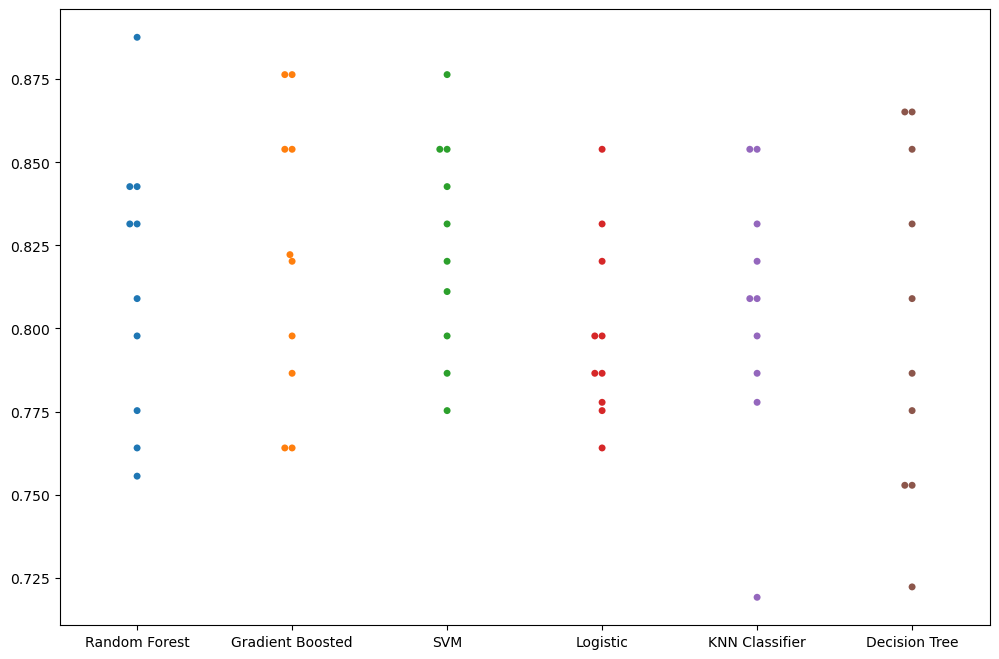

In [94]:
plt.figure(figsize=(12, 8))
sns.swarmplot(data = cross_val_df)
plt.show()

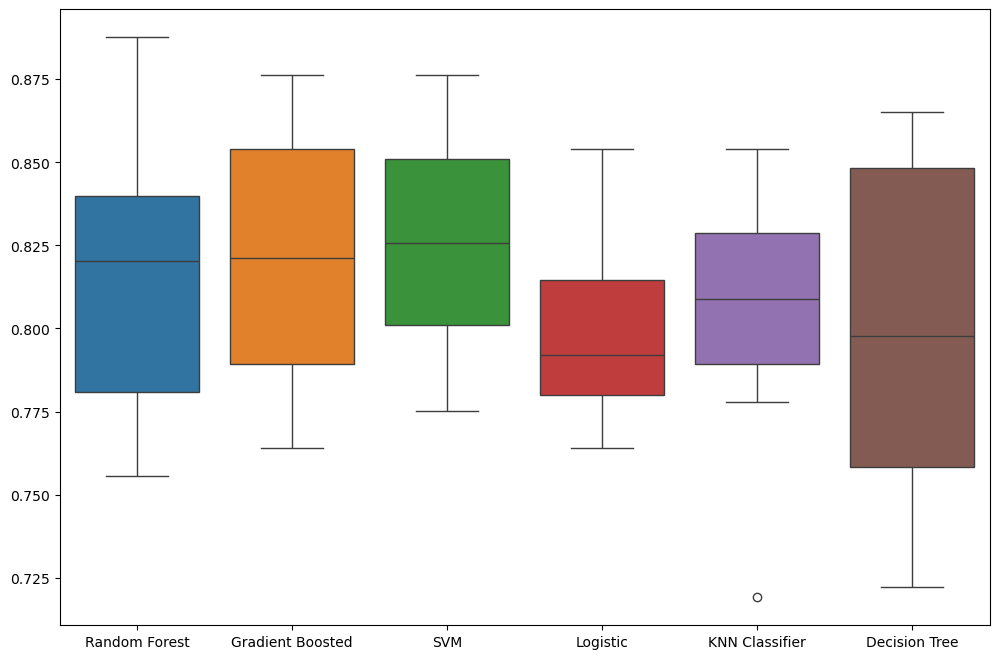

In [95]:
plt.figure(figsize=(12, 8))
sns.boxplot(data = cross_val_df)
plt.show()

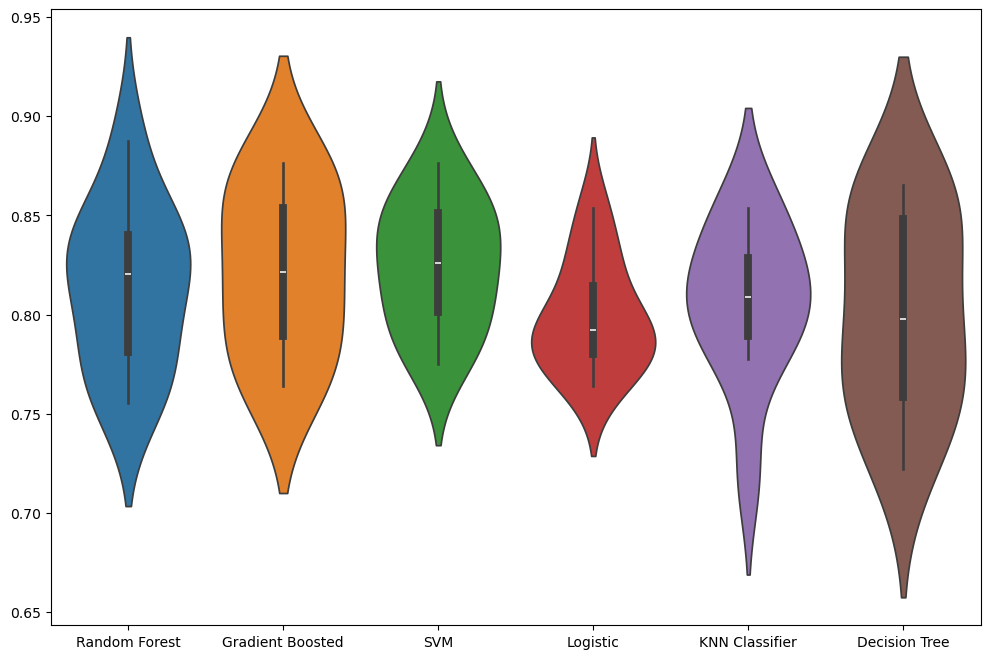

In [96]:
plt.figure(figsize=(12, 8))
sns.violinplot(data = cross_val_df)
plt.show()

* Focus on Random Forest, Gradient Boosted and SVM
     - doing grid search for best hyperparameters

In [97]:
from sklearn.model_selection import GridSearchCV

In [98]:
titanic_dataset_forest_pipeline = Pipeline([("rf_clf", RandomForestClassifier(random_state=42))
])


In [99]:
param_grid_forest = [{'rf_clf__n_estimators': [20, 40, 60, 80, 100, 120],
                     'rf_clf__max_depth': [None, 1, 2, 3, 4],
                     'rf_clf__min_samples_leaf': [1, 2, 4, 8, 16, 32, 64]}]
grid_search_forest = GridSearchCV(titanic_dataset_forest_pipeline, 
                              param_grid_forest, 
                              cv=10,
                              scoring='accuracy')
grid_search_forest.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('rf_clf',
                                        RandomForestClassifier(random_state=42))]),
             param_grid=[{'rf_clf__max_depth': [None, 1, 2, 3, 4],
                          'rf_clf__min_samples_leaf': [1, 2, 4, 8, 16, 32, 64],
                          'rf_clf__n_estimators': [20, 40, 60, 80, 100, 120]}],
             scoring='accuracy')

In [100]:
grid_search_forest.best_params_

{'rf_clf__max_depth': None,
 'rf_clf__min_samples_leaf': 4,
 'rf_clf__n_estimators': 100}

In [101]:
final_model_forest = grid_search_forest.best_estimator_ 
feature_importances = final_model_forest["rf_clf"].feature_importances_
feature_importances.round(2)

array([0.13, 0.04, 0.03, 0.18, 0.04, 0.02, 0.08, 0.2 , 0.25, 0.01, 0.01,
       0.01])

In [102]:
train_data.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [103]:
titanic_dataset_gb_pipeline = Pipeline([("gb_clf", GradientBoostingClassifier(random_state=42))
])


In [104]:
param_grid_gb = [{'gb_clf__n_estimators': [5, 10, 15, 20, 25],
                  'gb_clf__learning_rate': [0.05, 0.1, 0.2],
                     'gb_clf__max_depth': [None, 1, 2, 3, 4],
                     'gb_clf__min_samples_leaf': [1, 2, 4, 8, 16, 32]}]
grid_search_gb = GridSearchCV(titanic_dataset_gb_pipeline, 
                              param_grid_gb, 
                              cv=10,
                              scoring='accuracy')
grid_search_gb.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('gb_clf',
                                        GradientBoostingClassifier(random_state=42))]),
             param_grid=[{'gb_clf__learning_rate': [0.05, 0.1, 0.2],
                          'gb_clf__max_depth': [None, 1, 2, 3, 4],
                          'gb_clf__min_samples_leaf': [1, 2, 4, 8, 16, 32],
                          'gb_clf__n_estimators': [5, 10, 15, 20, 25]}],
             scoring='accuracy')

In [105]:
grid_search_gb.best_params_

{'gb_clf__learning_rate': 0.2,
 'gb_clf__max_depth': 4,
 'gb_clf__min_samples_leaf': 2,
 'gb_clf__n_estimators': 25}

In [106]:
final_model_gb = grid_search_gb.best_estimator_ 
feature_importances = final_model_gb["gb_clf"].feature_importances_
feature_importances.round(2)

array([0.14, 0.05, 0.  , 0.18, 0.03, 0.  , 0.11, 0.3 , 0.16, 0.01, 0.  ,
       0.01])

In [107]:
titanic_dataset_svm_pipeline = Pipeline([("svm_clf", SVC(gamma="auto", random_state=42))
])

In [108]:
param_grid_svm = [{'svm_clf__C': [1.0, 2.0, 4.0, 8.0, 16.0],
                  'svm_clf__degree': [1, 2, 3],
                     #'svm_clf__class_weight': [None, 'balanced'],
                     'svm_clf__kernel': ['linear', 'poly', 'rbf']}]
grid_search_svm = GridSearchCV(titanic_dataset_svm_pipeline, 
                              param_grid_svm, 
                              cv=10,
                              scoring='accuracy')
grid_search_svm.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('svm_clf',
                                        SVC(gamma='auto', random_state=42))]),
             param_grid=[{'svm_clf__C': [1.0, 2.0, 4.0, 8.0, 16.0],
                          'svm_clf__degree': [1, 2, 3],
                          'svm_clf__kernel': ['linear', 'poly', 'rbf']}],
             scoring='accuracy')

In [109]:
grid_search_svm.best_params_

{'svm_clf__C': 2.0, 'svm_clf__degree': 3, 'svm_clf__kernel': 'poly'}

In [110]:
titanic_dataset_dt_pipeline = Pipeline([("dt_clf", DecisionTreeClassifier(random_state=42))
])

In [111]:
param_grid_dt = [{'dt_clf__max_depth': [1, 2, 3, 4, 5, 6],
                  'dt_clf__min_samples_split': [2, 4, 8, 16, 32, 64, 128],
                     'dt_clf__max_features': [None, 1, 2, 3, 4, 5]}]
grid_search_dt = GridSearchCV(titanic_dataset_dt_pipeline, 
                              param_grid_dt, 
                              cv=10,
                              scoring='accuracy')
grid_search_dt.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('dt_clf',
                                        DecisionTreeClassifier(random_state=42))]),
             param_grid=[{'dt_clf__max_depth': [1, 2, 3, 4, 5, 6],
                          'dt_clf__max_features': [None, 1, 2, 3, 4, 5],
                          'dt_clf__min_samples_split': [2, 4, 8, 16, 32, 64,
                                                        128]}],
             scoring='accuracy')

In [112]:
grid_search_dt.best_params_

{'dt_clf__max_depth': 5,
 'dt_clf__max_features': 5,
 'dt_clf__min_samples_split': 2}

In [113]:
forest_clf = RandomForestClassifier(min_samples_leaf=4,
                                    n_estimators=100, 
                                    random_state=42)
forest_clf.fit(X_train, y_train)
forest_scores = cross_val_score(forest_clf, X_train, y_train, cv=10)
round(forest_scores.mean(),4)

np.float64(0.8362)

In [114]:
gb_model=GradientBoostingClassifier(learning_rate=0.2,
                                    max_depth=4,
                                    min_samples_leaf=2,
                                    n_estimators=25,
                                    random_state=42)
gb_model.fit(X_train, y_train)
gb_scores = cross_val_score(gb_model, X_train, y_train, cv=10)
round(gb_scores.mean(),4)

np.float64(0.8373)

In [115]:
svm_clf = SVC(C=2.0, degree=3, kernel='poly', gamma="auto", random_state=42)
svm_clf.fit(X_train, y_train)
svm_scores = cross_val_score(svm_clf, X_train, y_train, cv=10)
round(svm_scores.mean(),4)

np.float64(0.8294)

In [116]:
dt_clf = DecisionTreeClassifier(max_depth=5,
                                max_features=5, 
                                min_samples_split=2,
                                random_state=42)
dt_clf.fit(X_train, y_train)
dt_scores = cross_val_score(dt_clf, X_train, y_train, cv=10)
round(dt_scores.mean(),4)

np.float64(0.8272)

* 2% to 4% improvement using grid search
* Large improvement for Decision Tree from 0.80 to 0.83
* Since a white box model on par with black box models better to go with decision tree
     - Better tunability or interpretability
     - Understand the inner workings or decisions made by the model
     - Decision Tree also has tighter distribution for 10-fold cross validation

In [117]:
cross_val_df = pd.DataFrame({
    "Random Forest": pd.Series(forest_scores),
    "Gradient Boosted": pd.Series(gb_scores),
    "SVM": pd.Series(svm_scores),
    "Decision Tree": pd.Series(dt_scores),
    })

In [118]:
cross_val_df

,Random Forest,Gradient Boosted,SVM,Decision Tree
0,0.800000,0.800000,0.811111,0.833333
1,0.842697,0.831461,0.842697,0.842697
2,0.730337,0.741573,0.752809,0.764045
3,0.898876,0.898876,0.887640,0.865169
4,0.932584,0.910112,0.842697,0.865169
5,0.842697,0.853933,0.797753,0.831461
6,0.831461,0.820225,0.820225,0.797753
7,0.775281,0.786517,0.786517,0.764045
8,0.876404,0.876404,0.887640,0.887640
9,0.831461,0.853933,0.865169,0.820225


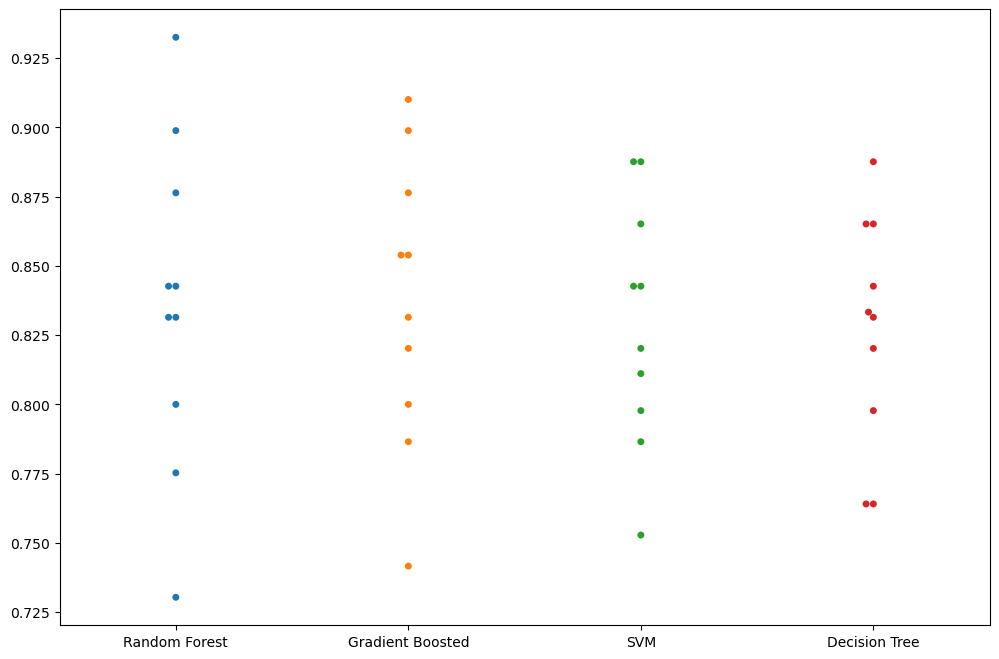

In [119]:
plt.figure(figsize=(12, 8))
sns.swarmplot(data = cross_val_df)
plt.show()

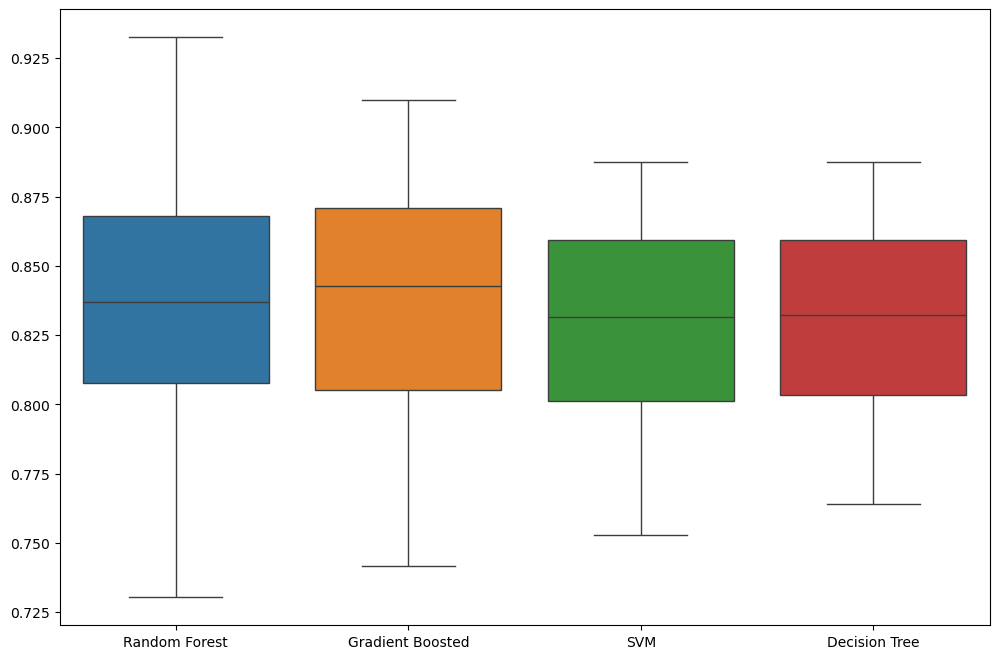

In [120]:
plt.figure(figsize=(12, 8))
sns.boxplot(data = cross_val_df)
plt.show()

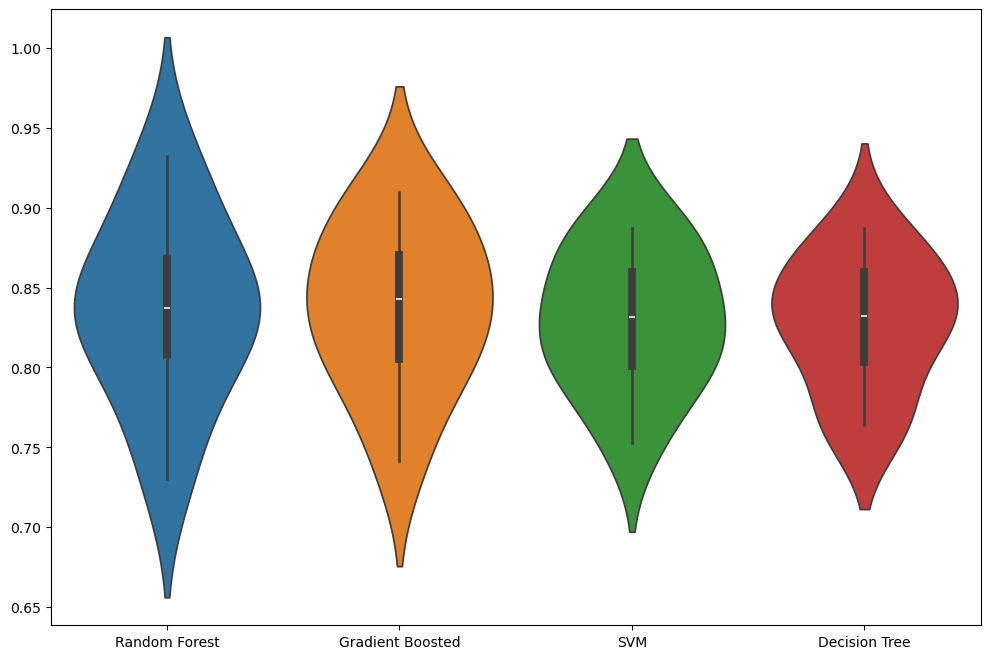

In [121]:
plt.figure(figsize=(12, 8))
sns.violinplot(data = cross_val_df)
plt.show()

In [122]:
forest_train_pred = forest_clf.predict(X_train)
print("-------------------------------------------------------------------------")
print(f"The accuraccy score:  {np.around(accuracy_score(y_train,
                                                          forest_train_pred), 4)}")
print("-------------------------------------------------------------------------")
print(f"The Confusion Matrix: \n{confusion_matrix(y_train,
                                                              forest_train_pred)}")
print("-------------------------------------------------------------------------")
print(f"The Classification Report: \n{classification_report(y_train,
                                                                    forest_train_pred)}")

-------------------------------------------------------------------------
The accuraccy score:  0.8822
-------------------------------------------------------------------------
The Confusion Matrix: 
[[521  28]
 [ 77 265]]
-------------------------------------------------------------------------
The Classification Report: 
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       549
           1       0.90      0.77      0.83       342

    accuracy                           0.88       891
   macro avg       0.89      0.86      0.87       891
weighted avg       0.88      0.88      0.88       891



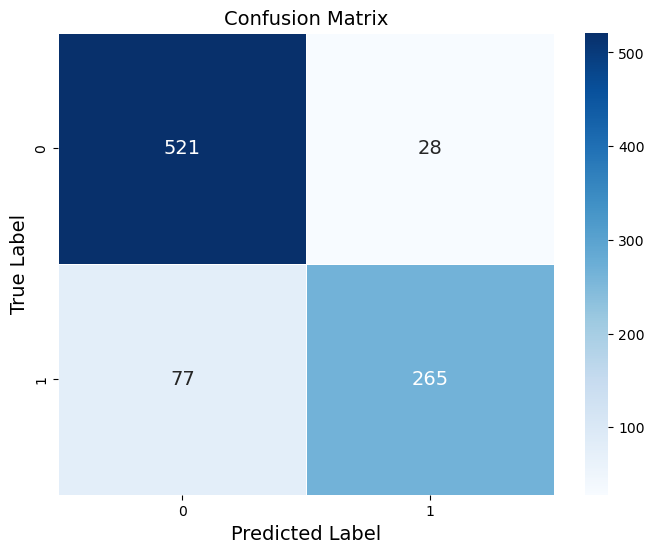

In [123]:
# Create a Pandas DataFrame
df_cm = pd.DataFrame(confusion_matrix(y_train, forest_train_pred), 
                     index=np.unique(y_train), 
                     columns=np.unique(y_train))

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", linewidths=.5)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [124]:
gb_train_pred = gb_model.predict(X_train)
print("-------------------------------------------------------------------------")
print(f"The accuraccy score:  {np.around(accuracy_score(y_train,
                                                          gb_train_pred), 4)}")
print("-------------------------------------------------------------------------")
print(f"The Confusion Matrix: \n{confusion_matrix(y_train,
                                                              gb_train_pred)}")
print("-------------------------------------------------------------------------")
print(f"The Classification Report: \n{classification_report(y_train,
                                                                    gb_train_pred)}")

-------------------------------------------------------------------------
The accuraccy score:  0.9068
-------------------------------------------------------------------------
The Confusion Matrix: 
[[529  20]
 [ 63 279]]
-------------------------------------------------------------------------
The Classification Report: 
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       549
           1       0.93      0.82      0.87       342

    accuracy                           0.91       891
   macro avg       0.91      0.89      0.90       891
weighted avg       0.91      0.91      0.91       891



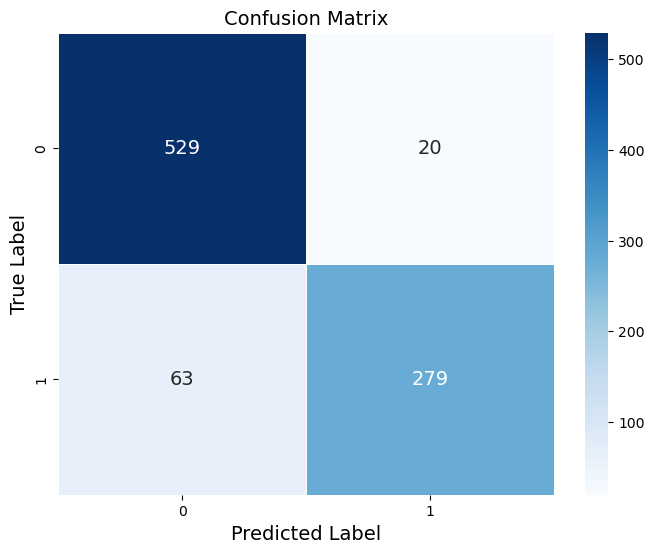

In [125]:
# Create a Pandas DataFrame
df_cm = pd.DataFrame(confusion_matrix(y_train, gb_train_pred), 
                     index=np.unique(y_train), 
                     columns=np.unique(y_train))

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", linewidths=.5)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [126]:
svm_train_pred = svm_clf.predict(X_train)
print("-------------------------------------------------------------------------")
print(f"The accuraccy score:  {np.around(accuracy_score(y_train,
                                                          svm_train_pred), 4)}")
print("-------------------------------------------------------------------------")
print(f"The Confusion Matrix: \n{confusion_matrix(y_train,
                                                              svm_train_pred)}")
print("-------------------------------------------------------------------------")
print(f"The Classification Report: \n{classification_report(y_train,
                                                                    svm_train_pred)}")

-------------------------------------------------------------------------
The accuraccy score:  0.8361
-------------------------------------------------------------------------
The Confusion Matrix: 
[[499  50]
 [ 96 246]]
-------------------------------------------------------------------------
The Classification Report: 
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       549
           1       0.83      0.72      0.77       342

    accuracy                           0.84       891
   macro avg       0.83      0.81      0.82       891
weighted avg       0.84      0.84      0.83       891



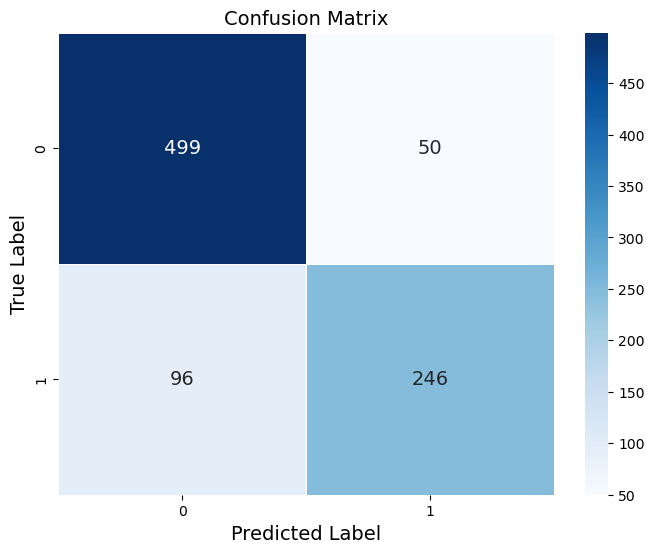

In [127]:
# Create a Pandas DataFrame
df_cm = pd.DataFrame(confusion_matrix(y_train, svm_train_pred), 
                     index=np.unique(y_train), 
                     columns=np.unique(y_train))

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", linewidths=.5)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [128]:
dt_train_pred = dt_clf.predict(X_train)
print("-------------------------------------------------------------------------")
print(f"The accuraccy score:  {np.around(accuracy_score(y_train,
                                                          dt_train_pred), 4)}")
print("-------------------------------------------------------------------------")
print(f"The Confusion Matrix: \n{confusion_matrix(y_train,
                                                              dt_train_pred)}")
print("-------------------------------------------------------------------------")
print(f"The Classification Report: \n{classification_report(y_train,
                                                                    dt_train_pred)}")

-------------------------------------------------------------------------
The accuraccy score:  0.8462
-------------------------------------------------------------------------
The Confusion Matrix: 
[[503  46]
 [ 91 251]]
-------------------------------------------------------------------------
The Classification Report: 
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       549
           1       0.85      0.73      0.79       342

    accuracy                           0.85       891
   macro avg       0.85      0.83      0.83       891
weighted avg       0.85      0.85      0.84       891



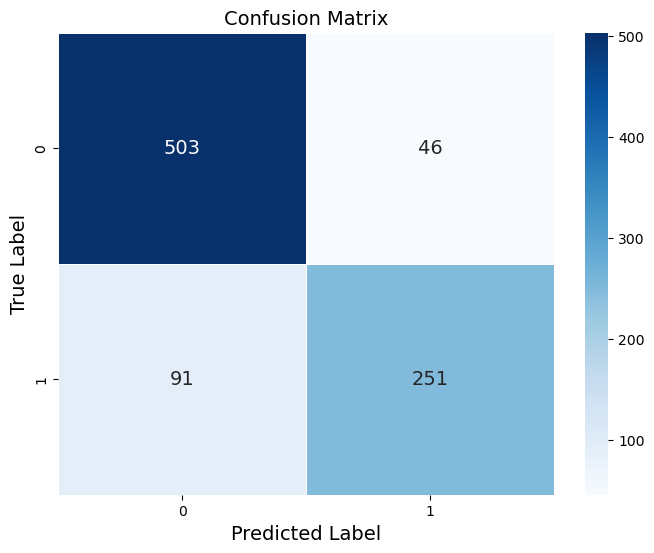

In [129]:
# Create a Pandas DataFrame
df_cm = pd.DataFrame(confusion_matrix(y_train, dt_train_pred), 
                     index=np.unique(y_train), 
                     columns=np.unique(y_train))

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", linewidths=.5)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()